In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance


## 1. OBTENCIÓN DE DATOS


In [3]:
# Usamos un dataset real de OpenML con miles de registros
adult = fetch_openml(name='adult', version=2, as_frame=True)
df = adult.frame

# Para propósitos de tiempo en la demostración/entrenamiento de SVM, tomaremos una muestra aleatoria robusta de 5,000 registros.
df = df.sample(n=5000, random_state=42).reset_index(drop=True)


## 2. PREPROCESAMIENTO Y LIMPIEZA

In [5]:
# A. Manejo de Nulos, reemplazamos los '?' por NaN que es el estándar
df.replace('?', np.nan, inplace=True)

# Eliminamos la columna 'education-num' porque es repetitiva con 'education'
df.drop(columns=['education-num'], inplace=True, errors='ignore')

# Imputación: Llenamos los nulos categóricos con la moda (¡Corregido el FutureWarning!)
for col in ['workclass', 'occupation', 'native-country']:
    df[col] = df[col].fillna(df[col].mode()[0])

# B. Transformación de Categóricas (Encoding)
# La variable objetivo 'class' es '>50K' o '<=50K'. La convertimos a 1 y 0.
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

# Convertimos las variables categóricas a numéricas usando One-Hot Encoding
# ¡ESTA ES LA LÍNEA QUE FALTABA!
df = pd.get_dummies(df, drop_first=True)

print(f"Forma del dataset preprocesado: {df.shape}")

Forma del dataset preprocesado: (5000, 97)


## 3. Separación de Datos (Evitando Fuga de Información)

In [7]:
# Variables predictoras y variable objetivo
X = df.drop(columns=['class'])
y = df['class']

# Dividimos con random_state para reproducibilidad y stratify para mantener el balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ESCALADO DE DATOS (Crítico en SVM y previene Data Leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Implementación del Modelo y Evaluación

Accuracy: 0.8490

Reporte de Clasificación:
              precision    recall  f1-score   support

       <=50K       0.87      0.94      0.90       760
        >50K       0.75      0.56      0.64       240

    accuracy                           0.85      1000
   macro avg       0.81      0.75      0.77      1000
weighted avg       0.84      0.85      0.84      1000



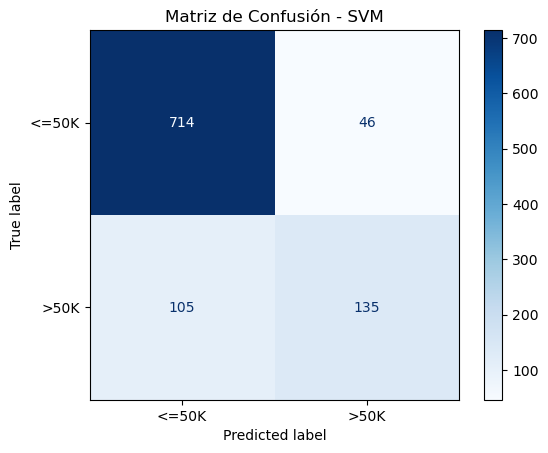


Muestra de las primeras 5 predicciones:


,Valor Real,Predicción SVM
1463,0,0
1342,1,1
4929,0,0
2048,0,0
676,1,0


In [9]:
# Instanciamos el modelo. Kernel RBF para lidiar con datos altamente no lineales.
modelo_svm = SVC(kernel='rbf', random_state=42)

# Entrenando modelo SVM (este proceso puede tomar unos segundos)
modelo_svm.fit(X_train_scaled, y_train)

# Generamos las predicciones con los datos de prueba
predicciones = modelo_svm.predict(X_test_scaled)
# Calculamos y mostramos el Accuracy
accuracy = accuracy_score(y_test, predicciones)
print(f"Accuracy: {accuracy:.4f}\n")

# Reporte de Clasificación (Precision, Recall, F1-score, Support)
print("Reporte de Clasificación:")
print(classification_report(y_test, predicciones, target_names=['<=50K', '>50K']))

# Matriz de Confusión
cm = confusion_matrix(y_test, predicciones)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - SVM")
plt.show()
#Se crea un dataFrame para poder visualizar los datos
resultados_df = pd.DataFrame({
    'Valor Real': y_test, 
    'Predicción SVM': predicciones
})
print("\nMuestra de las primeras 5 predicciones:")
display(resultados_df.head())

## 5. Importancia de las Variables (Feature Importance)

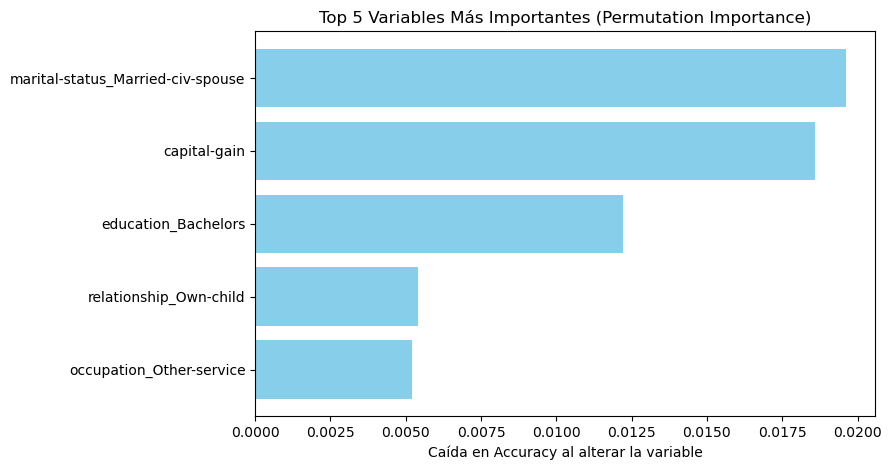

In [11]:
# Calculando Importancia de las Variables... (esto puede tomar unos segundos)
resultado = permutation_importance(modelo_svm, X_test_scaled, y_test, n_repeats=5, random_state=42)

# Obtenemos los índices de las 5 variables que más hacen caer el Accuracy si se alteran
top_indices = resultado.importances_mean.argsort()[-5:]

# Graficamos el top 5 de importancia
plt.figure(figsize=(8, 5))
plt.barh(X.columns[top_indices], resultado.importances_mean[top_indices], color='skyblue')
plt.title("Top 5 Variables Más Importantes (Permutation Importance)")
plt.xlabel("Caída en Accuracy al alterar la variable")
plt.show()

## 6. PREDICCIÓN CON DATOS NUEVOS

In [15]:
# Tomamos una fila de nuestro dataset original X para mantener la estructura de columnas,  pero modificamos los valores para simular una nueva persona externa al censo.
nuevo_dato = X.iloc[[0]].copy() 
nuevo_dato['age'] = 45
nuevo_dato['hours-per-week'] = 60

# 1. Transformamos los datos con el scaler ajustado previamente (Paso obligatorio)
nuevo_dato_scaled = scaler.transform(nuevo_dato)

# 2. Realizamos la predicción con nuestro modelo SVM
nueva_prediccion = modelo_svm.predict(nuevo_dato_scaled)

# 3. Formateamos el resultado final para mostrarlo de forma legible
resultado_texto = '>50K (Gana más de 50 mil)' if nueva_prediccion[0] == 1 else '<=50K (Gana 50 mil o menos)'
print(f"La predicción calculada para la nueva persona es: {resultado_texto}")

La predicción calculada para la nueva persona es: <=50K (Gana 50 mil o menos)
